# Clasificación de supervivencia en el Titanic

En este notebook entrenamos y comparamos tres modelos de clasificación
para predecir si un pasajero del Titanic sobrevivió o no:

1. **Árbol de Decisión** — modelo interpretable, fácil de visualizar.
2. **XGBoost** — *boosting* de árboles, normalmente el más preciso.
3. **Regresión Logística** — modelo lineal de referencia (Clase 12).

El hilo conductor es: partir de un modelo simple, detectar sus problemas
(sobreajuste y desbalanceo de clases), corregirlos y, finalmente,
**afinar los hiperparámetros con bucles `for`** y comparar todo de forma justa.


## 1. Carga de datos y preprocesamiento

Cargamos el dataset del Titanic y lo dejamos listo para los modelos:
imputamos los valores que faltan (`Age`, `Embarked`), codificamos las
variables categóricas con *one-hot encoding* y escalamos las numéricas.
Por último, separamos en conjuntos de **entrenamiento (80%)** y **test (20%)**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler

# Cargamos el MISMO dataset que en la Clase 12
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# ── Preprocesado idéntico a la Clase 12 ──────────────────────────────
y = df['Survived']
X = df.drop(columns=['Survived','PassengerId','Name','Ticket','Cabin'])

# Imputación contextual de Age (mediana por Pclass + Sex) — Clase 5
X['Age'] = X['Age'].fillna(
    X.groupby(['Pclass','Sex'])['Age'].transform('median'))
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

# Codificación de variables categóricas
X = pd.get_dummies(X, columns=['Pclass','Sex','Embarked'], drop_first=True)

# Escalado (el árbol NO lo necesita, pero lo dejamos para que la
# regresión logística compita en igualdad de condiciones)
cols_num = ['Age','Fare','SibSp','Parch']
scaler = StandardScaler()
X[cols_num] = scaler.fit_transform(X[cols_num])

# Train/test split idéntico
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]}  │  Test: {X_test.shape[0]}')


Train: 712  │  Test: 179


**¿El árbol necesita escalado?** No.
Los árboles solo comparan umbrales ("¿Fare > 30?"), así que la escala de cada variable les da igual: escalemos o no, el árbol sale idéntico. Entonces, ¿por qué escalamos aquí? Porque la regresión logística sí lo necesita, y queremos que ambos modelos usen exactamente los mismos datos para que la comparación final sea justa.


## 2. Árbol de decisión sin podar (diagnóstico de sobreajuste)

Primero dejamos que el árbol crezca **sin límites**. Comparamos su
*accuracy* en train y en test: si acierta casi todo en train pero mucho
menos en test, es la señal típica de **sobreajuste** (ha memorizado el
ruido de los datos de entrenamiento).


In [2]:
# Árbol sin podar: lo dejamos crecer todo lo que quiera
arbol_full = DecisionTreeClassifier(random_state=42)
arbol_full.fit(X_train, y_train)

# Evaluamos en TRAIN y en TEST para detectar el sobreajuste
acc_train = accuracy_score(y_train, arbol_full.predict(X_train))
acc_test  = accuracy_score(y_test,  arbol_full.predict(X_test))

print(f'Accuracy en TRAIN: {acc_train*100:.1f}%')
print(f'Accuracy en TEST:  {acc_test*100:.1f}%')
print(f'Profundidad del árbol: {arbol_full.get_depth()}')
print(f'Número de hojas:       {arbol_full.get_n_leaves()}')


Accuracy en TRAIN: 98.3%
Accuracy en TEST:  79.9%
Profundidad del árbol: 22
Número de hojas:       154


## 3. Árbol de decisión podado

Limitamos el crecimiento del árbol (`max_depth` y `min_samples_leaf`)
para obligarlo a aprender solo los patrones generales. Volvemos a medir
la brecha train-test: debería reducirse respecto al árbol sin podar.


In [3]:
# Limitamos el crecimiento para forzar al árbol a aprender solo
# los patrones generales, no el ruido
arbol = DecisionTreeClassifier(
    max_depth=4,          # como mucho 4 preguntas encadenadas
    min_samples_leaf=20,  # cada hoja debe tener al menos 20 pasajeros
    random_state=42)
arbol.fit(X_train, y_train)

acc_train = accuracy_score(y_train, arbol.predict(X_train))
acc_test  = accuracy_score(y_test,  arbol.predict(X_test))
print(f'Accuracy en TRAIN: {acc_train*100:.1f}%')
print(f'Accuracy en TEST:  {acc_test*100:.1f}%')
gap = acc_train - acc_test
print(f'Brecha train-test: {gap*100:.1f} puntos',
      'revisar' if gap > 0.10 else '✅ saludable')


Accuracy en TRAIN: 83.0%
Accuracy en TEST:  78.2%
Brecha train-test: 4.8 puntos ✅ saludable


## 4. Visualización del árbol

Dibujamos el árbol completo con todas sus hojas. Gracias a
`proportion=True`, **cada hoja muestra la probabilidad** de cada clase
(no el número de pasajeros), y el color indica la clase predicha.

> **Cómo leer una hoja:** el nombre de la clase (`Sobrevivió` /
> `No sobrevivió`) es la **predicción final** de esa hoja, y el campo
> `value = [p0, p1]` son las **probabilidades** P(No sobrevivió) y
> P(Sobrevivió) que asigna el árbol a cualquier pasajero que caiga ahí.


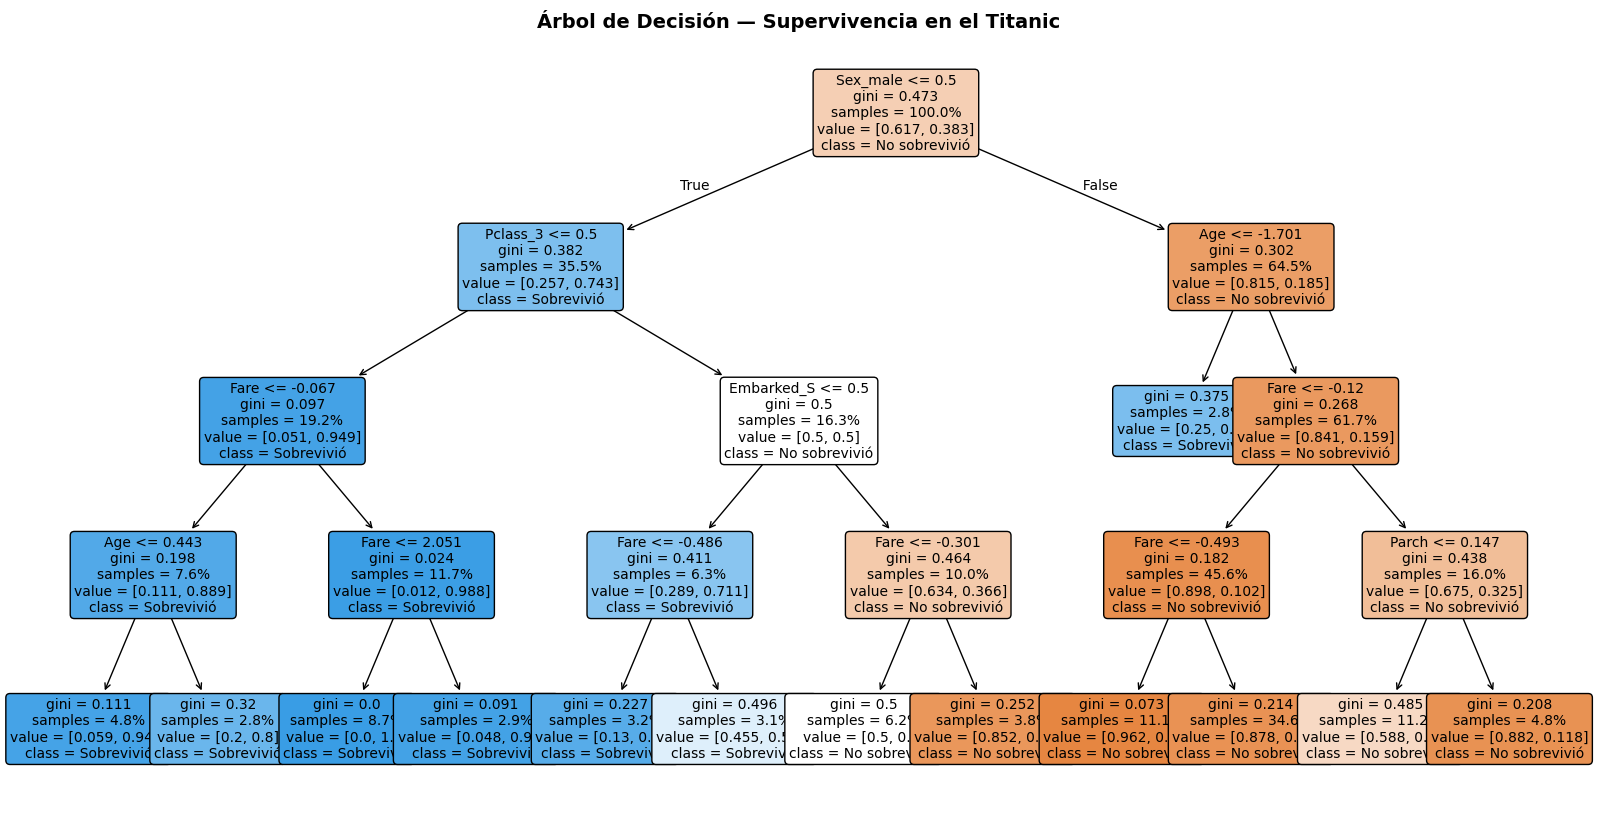

In [4]:
plt.figure(figsize=(20, 10))
plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=['No sobrevivió','Sobrevivió'],
    filled=True,        # colorea según la clase dominante de cada nodo
    proportion=True,    # muestra PROPORCIONES (probabilidades) en cada hoja
    rounded=True,
    fontsize=10)
plt.title('Árbol de Decisión — Supervivencia en el Titanic',
          fontsize=14, fontweight='bold')
plt.show()


### 4.1. Predicción final y probabilidad por pasajero

El gráfico muestra el árbol entero; aquí lo traducimos en una respuesta
concreta para cada pasajero del conjunto de test:

- `predict`       → la **clase final** (¿sobrevivió o no?).
- `predict_proba` → la **probabilidad** de cada clase, que es exactamente
  la proporción que muestra la hoja en la que cae el pasajero.


In [6]:
# ── Predicción final y probabilidad de cada pasajero ────────────────
# Usamos el árbol podado (el mismo que hemos dibujado arriba).
pred_clase = arbol.predict(X_test)            # 0 = No sobrevivió, 1 = Sobrevivió
pred_proba = arbol.predict_proba(X_test)      # [P(No sobrevivió), P(Sobrevivió)]

resultado = pd.DataFrame({
    'Predicción':       np.where(pred_clase == 1, 'Sobrevivió', 'No sobrevivió'),
    'P(No sobrevivió)': (pred_proba[:, 0] * 100).round(1),
    'P(Sobrevivió)':    (pred_proba[:, 1] * 100).round(1),
    'Real':             np.where(y_test.values == 1, 'Sobrevivió', 'No sobrevivió'),
}, index=X_test.index)

# Mostramos los 10 primeros pasajeros del test
print('Predicción y probabilidad por pasajero (primeros 10 del test):')
print(resultado.head(10).to_string())

# Ejemplo individual: veredicto del árbol para un pasajero concreto
i = 0
clase = 'Sobrevivió' if pred_clase[i] == 1 else 'No sobrevivió'
print(f'\nPasajero {X_test.index[i]} -> {clase} '
      f'(probabilidad de supervivencia: {pred_proba[i, 1]*100:.1f}%)')

Predicción y probabilidad por pasajero (primeros 10 del test):
        Predicción  P(No sobrevivió)  P(Sobrevivió)           Real
565  No sobrevivió              87.8           12.2  No sobrevivió
160  No sobrevivió              87.8           12.2  No sobrevivió
553  No sobrevivió              96.2            3.8     Sobrevivió
860  No sobrevivió              87.8           12.2  No sobrevivió
241     Sobrevivió              45.5           54.5     Sobrevivió
559  No sobrevivió              85.2           14.8     Sobrevivió
387     Sobrevivió              20.0           80.0     Sobrevivió
536  No sobrevivió              58.8           41.2  No sobrevivió
698  No sobrevivió              88.2           11.8  No sobrevivió
99   No sobrevivió              87.8           12.2  No sobrevivió

Pasajero 565 -> No sobrevivió (probabilidad de supervivencia: 12.2%)


## 5. Importancia de las variables

¿En qué variables se apoya el árbol para decidir? La importancia mide
cuánto reduce cada variable la impureza (Gini) a lo largo del árbol.


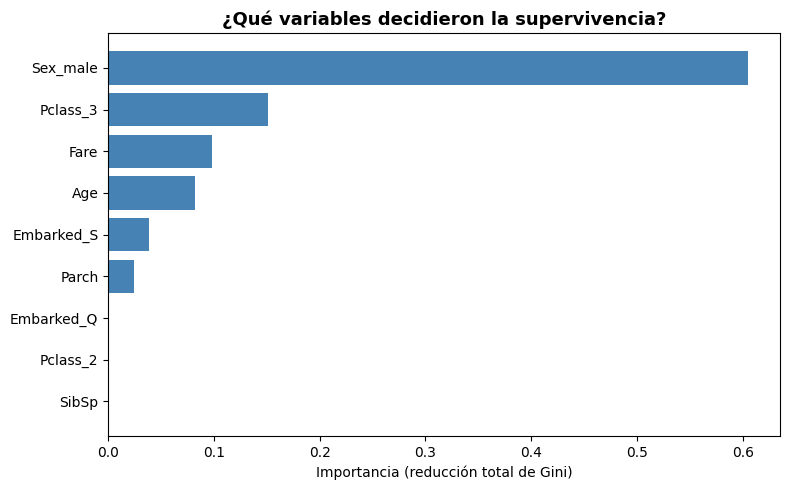

     variable  importancia
6    Sex_male     0.604886
5    Pclass_3     0.150827
3        Fare     0.098050
0         Age     0.082478
8  Embarked_S     0.039043
2       Parch     0.024716
1       SibSp     0.000000
4    Pclass_2     0.000000
7  Embarked_Q     0.000000


In [7]:
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': arbol.feature_importances_
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancias['variable'], importancias['importancia'],
        color='steelblue')
ax.set_xlabel('Importancia (reducción total de Gini)')
ax.set_title('¿Qué variables decidieron la supervivencia?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(importancias.sort_values('importancia', ascending=False))


## 6. Distribución de la clase objetivo (desbalanceo)

Comprobamos cuántos pasajeros sobrevivieron frente a los que no. Si las
clases están desbalanceadas, el modelo tenderá a favorecer a la mayoritaria.


In [8]:
print('Distribución de la variable objetivo (Survived):')
print(y.value_counts())
print()
print((y.value_counts(normalize=True) * 100).round(1))


Distribución de la variable objetivo (Survived):
Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64


## 7. Árbol balanceado (`class_weight='balanced'`)

Repetimos el árbol podado pero penalizando más los errores sobre la clase
minoritaria. Comparamos el `classification_report` con y sin balanceo:
debería mejorar el *recall* de la clase "Sobrevivió".


In [9]:
# Mismo árbol podado, pero ahora consciente del desbalanceo
arbol_bal = DecisionTreeClassifier(
    max_depth=4, min_samples_leaf=20,
    class_weight='balanced',   # <-- la única línea nueva
    random_state=42)
arbol_bal.fit(X_train, y_train)

print('── SIN balancear ──')
print(classification_report(y_test, arbol.predict(X_test),
      target_names=['No sobrevivió','Sobrevivió']))

print('── CON class_weight="balanced" ──')
print(classification_report(y_test, arbol_bal.predict(X_test),
      target_names=['No sobrevivió','Sobrevivió']))


── SIN balancear ──
               precision    recall  f1-score   support

No sobrevivió       0.77      0.92      0.84       110
   Sobrevivió       0.81      0.57      0.67        69

     accuracy                           0.78       179
    macro avg       0.79      0.74      0.75       179
 weighted avg       0.79      0.78      0.77       179

── CON class_weight="balanced" ──
               precision    recall  f1-score   support

No sobrevivió       0.83      0.75      0.78       110
   Sobrevivió       0.65      0.75      0.70        69

     accuracy                           0.75       179
    macro avg       0.74      0.75      0.74       179
 weighted avg       0.76      0.75      0.75       179



## 8. XGBoost

XGBoost encadena muchos árboles pequeños donde cada uno corrige los
errores del anterior (*gradient boosting*). Suele ser el modelo más
preciso, a costa de ser menos interpretable que un único árbol.


In [10]:
# XGBoost no viene en scikit-learn. En Google Colab ya está instalado;
# si no, descomentad la línea siguiente:
# !pip install xgboost

from xgboost import XGBClassifier

# scale_pos_weight es el equivalente a class_weight="balanced" en XGBoost:
# le indicamos cuántas veces es más frecuente la clase 0 que la 1
peso = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,       # número de árboles encadenados
    max_depth=3,            # árboles poco profundos (weak learners)
    learning_rate=0.1,      # cuánto corrige cada árbol al anterior
    scale_pos_weight=peso,  # manejo del desbalanceo
    random_state=42,
    eval_metric='logloss')
xgb.fit(X_train, y_train)

acc_train = accuracy_score(y_train, xgb.predict(X_train))
acc_test  = accuracy_score(y_test,  xgb.predict(X_test))
print(f'XGBoost — Accuracy TRAIN: {acc_train*100:.1f}%  |  TEST: {acc_test*100:.1f}%')


XGBoost — Accuracy TRAIN: 90.9%  |  TEST: 80.4%


## 9. Búsqueda de hiperparámetros con bucles `for`

Hasta ahora hemos fijado los hiperparámetros **a mano** (`max_depth=4`,
`learning_rate=0.1`...). Aquí los buscamos de forma sistemática recorriendo
combinaciones con **bucles `for` anidados**.

> **Importante (metodología):** no usamos el conjunto de *test* para elegir
> los hiperparámetros (sería hacer trampa). Evaluamos cada combinación con
> **validación cruzada (5 folds) sobre el conjunto de entrenamiento** y solo
> al final medimos el mejor modelo una única vez sobre el test.


### 9.1. Árbol de decisión: `max_depth` y `min_samples_leaf`

In [11]:
from sklearn.model_selection import cross_val_score

# Rejilla de valores a probar para el ÁRBOL
profundidades   = [2, 3, 4, 5, 6, 8]      # 'profundidad' del árbol
min_hojas       = [5, 10, 20, 30]         # mínimo de muestras por hoja

resultados_arbol = []

# Bucles for anidados: probamos TODAS las combinaciones
for prof in profundidades:
    for mh in min_hojas:
        modelo = DecisionTreeClassifier(
            max_depth=prof,
            min_samples_leaf=mh,
            class_weight='balanced',
            random_state=42)
        # F1 medio con validación cruzada de 5 folds (solo sobre train)
        f1_cv = cross_val_score(modelo, X_train, y_train,
                                cv=5, scoring='f1').mean()
        resultados_arbol.append(
            {'max_depth': prof, 'min_samples_leaf': mh, 'F1_cv': f1_cv})

# Ordenamos de mejor a peor
tabla_arbol = (pd.DataFrame(resultados_arbol)
               .sort_values('F1_cv', ascending=False)
               .reset_index(drop=True))
tabla_arbol['F1_cv'] = tabla_arbol['F1_cv'].round(4)

print('Top 5 combinaciones para el árbol:')
print(tabla_arbol.head().to_string(index=False))

mejor_arbol = tabla_arbol.iloc[0]
print(f"\nMejor combinación -> max_depth={int(mejor_arbol['max_depth'])}, "
      f"min_samples_leaf={int(mejor_arbol['min_samples_leaf'])} "
      f"(F1 CV = {mejor_arbol['F1_cv']})")

Top 5 combinaciones para el árbol:
 max_depth  min_samples_leaf  F1_cv
         8                 5 0.7427
         6                 5 0.7407
         2                 5 0.7325
         2                10 0.7216
         8                10 0.7203

Mejor combinación -> max_depth=8, min_samples_leaf=5 (F1 CV = 0.7427)


### 9.2. XGBoost: `max_depth`, `learning_rate` y `n_estimators`

Aquí entran en juego los tres hiperparámetros que pedía el enunciado:
**profundidad**, **learning rate** y el **número de árboles**.


In [12]:
# Rejilla de valores a probar para XGBOOST
profundidades_xgb = [2, 3, 4]            # profundidad de cada árbol
learning_rates    = [0.01, 0.05, 0.1, 0.3]  # learning rate
n_arboles         = [100, 200, 300]      # número de árboles encadenados

resultados_xgb = []

# Bucles for anidados sobre los tres hiperparámetros
for prof in profundidades_xgb:
    for lr in learning_rates:
        for n in n_arboles:
            modelo = XGBClassifier(
                max_depth=prof,
                learning_rate=lr,
                n_estimators=n,
                scale_pos_weight=peso,   # manejo del desbalanceo (definido antes)
                random_state=42,
                eval_metric='logloss')
            f1_cv = cross_val_score(modelo, X_train, y_train,
                                    cv=5, scoring='f1').mean()
            resultados_xgb.append({
                'max_depth': prof, 'learning_rate': lr,
                'n_estimators': n, 'F1_cv': f1_cv})

tabla_xgb = (pd.DataFrame(resultados_xgb)
             .sort_values('F1_cv', ascending=False)
             .reset_index(drop=True))
tabla_xgb['F1_cv'] = tabla_xgb['F1_cv'].round(4)

print('Top 5 combinaciones para XGBoost:')
print(tabla_xgb.head().to_string(index=False))

# Reentrenamos XGBoost con la MEJOR combinación encontrada
mejor = tabla_xgb.iloc[0]
print(f"\nMejor combinación -> max_depth={int(mejor['max_depth'])}, "
      f"learning_rate={mejor['learning_rate']}, "
      f"n_estimators={int(mejor['n_estimators'])} (F1 CV = {mejor['F1_cv']})")

xgb_best = XGBClassifier(
    max_depth=int(mejor['max_depth']),
    learning_rate=float(mejor['learning_rate']),
    n_estimators=int(mejor['n_estimators']),
    scale_pos_weight=peso,
    random_state=42,
    eval_metric='logloss')
xgb_best.fit(X_train, y_train)

# Ahora sí, evaluación FINAL (una sola vez) sobre el test
acc_test = accuracy_score(y_test, xgb_best.predict(X_test))
print(f'XGBoost afinado — Accuracy en TEST: {acc_test*100:.1f}%')

Top 5 combinaciones para XGBoost:
 max_depth  learning_rate  n_estimators  F1_cv
         2           0.10           200 0.7631
         2           0.10           300 0.7629
         2           0.30           100 0.7613
         3           0.10           200 0.7606
         2           0.05           300 0.7598

Mejor combinación -> max_depth=2, learning_rate=0.1, n_estimators=200 (F1 CV = 0.7631)
XGBoost afinado — Accuracy en TEST: 79.3%


## 10. Comparación final de modelos

Reentrenamos la regresión logística (balanceada) y comparamos los tres
modelos con las cuatro métricas clave: *Accuracy*, *Precision*, *Recall*
y *F1*. Incluimos el XGBoost afinado en el apartado anterior.


In [13]:
# Reentrenamos la regresión logística de la Clase 12, ahora balanceada
logistica = LogisticRegression(max_iter=1000,
                               class_weight='balanced',
                               random_state=42)
logistica.fit(X_train, y_train)

# Función que resume las 4 métricas de un modelo sobre el TEST
def metricas(modelo, nombre):
    pred = modelo.predict(X_test)
    return {
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred)
    }

tabla = pd.DataFrame([
    metricas(logistica, 'Regresión Logística'),
    metricas(arbol_bal, 'Árbol de Decisión'),
    metricas(xgb,       'XGBoost (manual)'),
    metricas(xgb_best,  'XGBoost (afinado)')
]).set_index('Modelo').round(3)

print(tabla)


                     Accuracy  Precision  Recall     F1
Modelo                                                 
Regresión Logística     0.810      0.746   0.768  0.757
Árbol de Decisión       0.749      0.650   0.754  0.698
XGBoost (manual)        0.804      0.766   0.710  0.737
XGBoost (afinado)       0.793      0.742   0.710  0.726


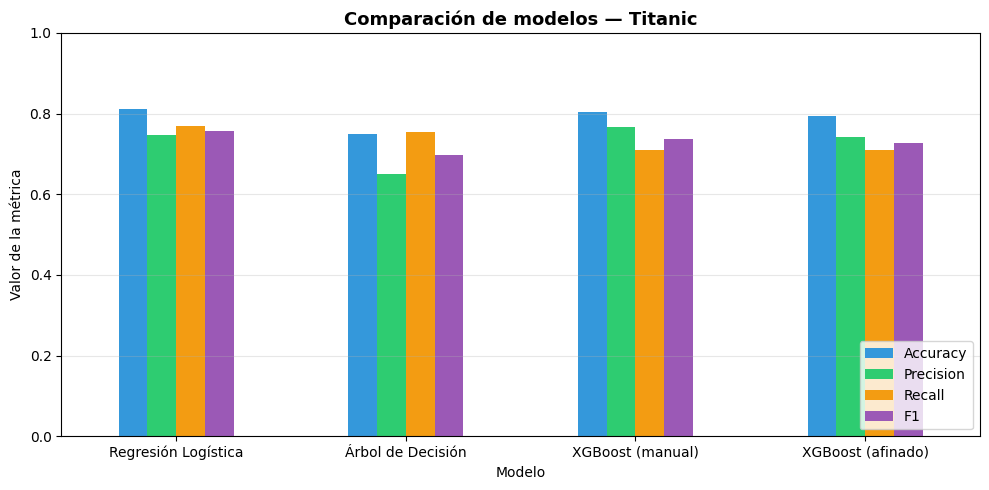

In [14]:
# Gráfico comparativo de las 4 métricas
tabla.plot.bar(figsize=(10, 5), rot=0,
               color=['#3498DB','#2ECC71','#F39C12','#9B59B6'])
plt.title('Comparación de modelos — Titanic',
          fontsize=13, fontweight='bold')
plt.ylabel('Valor de la métrica')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
